# z950 — Canaritos Asesinos (brazo A) vs Boruta (brazo B)

**Hipótesis original:** Canaritos (`ratio=0.2, desvios=2`, LightGBM custom ganancia-meseta) es más rápido que Boruta (`ranger, ntree=100, maxRuns=15, pValue=0.05, Bonferroni, sin class weights`) sin degradar ganancia pública ni AUC.

Diseño pareado por semilla primigenia: `exp/WF9500_s{seed}/` (A) vs `exp/WF9503_s{seed}/` (B), mismo notebook z950, solo cambia el paso 4 (selector).

**Fuente de timings:** metadatos *papermill* de `salida_corrida*.ipynb` (duración exacta por celda y del run completo). Los logs `corrida_exp*.log` se usan solo como cross-check de estados FIN OK/ERROR.

Secciones:
1. Wall-clock y stages por semilla (FS / BO / semillerio / Kaggle).
2. Compresión: `k` variables y Jaccard entre brazos.
3. AUC del BO (pareado).
4. Ganancia vs envios — pendiente export de Kaggle (plantilla lista).
5. Decisión.

> Correr con kernel **R** desde la raíz del repo.

In [7]:
suppressPackageStartupMessages({library(data.table); library(jsonlite)})
Sys.setlocale("LC_TIME", "C")

# ubicar la raiz del repo (donde viven semillas/ y exp/) sin importar desde donde
# se haya lanzado jupyter -- ojo: src/workflows/ TAMBIEN tiene semillas y exp/
find_root <- function() {
  d <- getwd()
  repeat {
    if (dir.exists(file.path(d, "exp", "WF9500_s169327"))) return(normalizePath(d))
    p <- dirname(d)
    if (p == d) stop("No encuentro exp/WF9500_s169327 hacia arriba. Lanzar jupyter desde la raiz del repo.")
    d <- p
  }
}
ROOT <- find_root()
if (normalizePath(ROOT) != normalizePath(getwd())) {
  cat("cwd era:", getwd(), "-> moviendo a raiz del repo:", ROOT, "\n")
  setwd(ROOT)
}

EXP_A <- 9500L   # Canaritos Asesinos
EXP_B <- 9503L   # Boruta
EXP_C <- 9504L   # Canaritos Warmstart v2 (HS 32..256, prioriza 9500, 30it)
ARM_A <- "Canaritos"
ARM_B <- "Boruta"
ARM_C <- "Warmstart9504"

SEEDS <- as.integer(grep("^\\d+$", readLines("semillas"), value = TRUE))
N_SEEDS <- 5L
SEEDS <- head(SEEDS, N_SEEDS)
SEEDS

exp_dir <- function(exp, seed) sprintf("exp/WF%d_s%d", exp, seed)

# el notebook de salida correcto por experimento (los resumes fallidos escriben
# salida_corrida_exp{OTRO}.ipynb en la misma carpeta -> excluirlos)
salida_nb <- function(exp, seed) {
  d <- exp_dir(exp, seed)
  cand <- list.files(d, pattern = "^salida_corrida.*\\.ipynb$", full.names = TRUE)
  exact <- sprintf("%s/salida_corrida_exp%d.ipynb", d, exp)
  if (file.exists(exact)) return(exact)
  plain <- file.path(d, "salida_corrida.ipynb")
  cand <- setdiff(cand, grep("salida_corrida_exp\\d+", cand, value = TRUE))
  if (file.exists(plain)) return(plain)
  if (length(cand)) return(cand[1])
  NA_character_
}

[1] "C"

[1] 644857 218249 493747 655103 169327

## 1. Q1 Costo — wall-clock y stages desde papermill

Cada celda ejecutada lleva `metadata.papermill.duration`. Clasificamos:
- **FS**: celda(s) con `CanaritosAsesinos(`/`BorutaSelector(`
- **BO**: celda con `mbo(`
- **Semillerio**: celdas de `crear_modelo_final` / entrenamiento final
- **Kaggle**: generación/subida de envíos
- resto → **otro**

In [8]:
stage_of <- function(src) {
  if (grepl("CanaritosAsesinos\\(|BorutaSelector\\(", src)) return("FS")
  if (grepl("\\bmbo\\(", src)) return("BO")
  if (grepl("crear_modelo_final|PARAM\\$FT\\$semillerio", src)) return("Semillerio")
  if (grepl("genero archivos|fsubmit|competencia", src, ignore.case = TRUE)) return("Kaggle")
  "otro"
}

nb_stages <- function(exp, seed) {
  f <- salida_nb(exp, seed)
  if (is.na(f)) return(NULL)
  nb <- jsonlite::fromJSON(f, simplifyVector = FALSE)
  tot <- nb$metadata$papermill$duration
  rows <- lapply(nb$cells, function(c) {
    if (c$cell_type != "code") return(NULL)
    pm <- c$metadata$papermill
    if (is.null(pm$duration)) return(NULL)
    data.table(stage = stage_of(paste(unlist(c$source), collapse = "")),
               min = pm$duration / 60)
  })
  out <- rbindlist(Filter(Negate(is.null), rows))
  out[, .(min = sum(min)), by = stage][order(-min)][]
}

stages_all <- rbindlist(lapply(SEEDS, function(s) {
  a <- nb_stages(EXP_A, s); if (!is.null(a)) a[, `:=`(arm = ARM_A, seed = s)]
  b <- nb_stages(EXP_B, s); if (!is.null(b)) b[, `:=`(arm = ARM_B, seed = s)]
  rbindlist(list(a, b), use.names = TRUE, fill = TRUE)
}), use.names = TRUE)
stopifnot(nrow(stages_all) > 0,
          all(c("stage", "min", "arm", "seed") %in% names(stages_all)))

# tabla ancha: un row por arm/seed con cada stage + total
stages_wide <- dcast(stages_all, arm + seed ~ stage, value.var = "min", fill = 0)
stages_wide[, total := rowSums(.SD), .SDcols = setdiff(names(stages_wide), c("arm", "seed"))]
# corrida completa = pasó por semillerio y Kaggle (los truncados por preempción no)
stages_wide[, completo := Semillerio > 0 & Kaggle > 0]
setcolorder(stages_wide, intersect(c("arm","seed","FS","BO","Semillerio","Kaggle","otro","total","completo"),
                                   names(stages_wide)))
stages_wide[]
cat("\nCorridas posiblemente INCOMPLETAS (sin etapa semillerio/Kaggle):\n")
print(stages_wide[completo == FALSE, .(arm, seed, total)])
cat("\n-> Excluirlas de promedios o re-correr. Filtrar con stages_wide[completo == TRUE]\n")

arm,seed,FS,BO,Semillerio,Kaggle,otro,total,completo
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
Boruta,169327,86.37854675,27.54097,41.015864,4.862680800,9.019644,168.817704,TRUE
Boruta,218249,114.60878843,31.48887,31.742075,4.855885633,10.981866,193.677484,TRUE
Boruta,493747,0.01591057,0.00000,0.000000,0.002428083,9.842313,9.860652,FALSE
Boruta,644857,115.28589702,29.58077,49.802393,4.856184750,10.961330,210.486578,TRUE
Boruta,655103,86.82063008,19.82903,7.528212,4.894102050,8.848294,127.920266,TRUE
Canaritos,169327,2.14269417,116.49024,254.511765,4.839523050,10.961130,388.945355,TRUE
Canaritos,218249,2.11277168,92.58708,300.550012,4.816091067,10.302041,410.367998,TRUE
Canaritos,493747,1.98260445,199.24537,269.945693,4.828087617,10.755167,486.756922,TRUE
Canaritos,644857,2.03327940,79.64153,108.220643,4.866866617,9.611381,204.373705,TRUE



Corridas posiblemente INCOMPLETAS (sin etapa semillerio/Kaggle):
Key: <arm, seed>
      arm   seed    total
   <char>  <int>    <num>
1: Boruta 493747 9.860652

-> Excluirlas de promedios o re-correr. Filtrar con stages_wide[completo == TRUE]


Key: <seed>
     seed  total_B  total_A delta_B_minus_A ratio_B_A
    <int>    <num>    <num>           <num>     <num>
1: 169327 168.8177 388.9454          -220.1      0.43
2: 218249 193.6775 410.3680          -216.7      0.47
3: 493747       NA 486.7569              NA        NA
4: 644857 210.4866 204.3737             6.1      1.03
5: 655103 127.9203 320.0588          -192.1      0.40

	Wilcoxon signed rank exact test

data:  tw$total_B[okt] and tw$total_A[okt]
V = 1, p-value = 0.25
alternative hypothesis: true location shift is not equal to 0


Total medio — Canaritos: 362 min | Boruta: 175 min


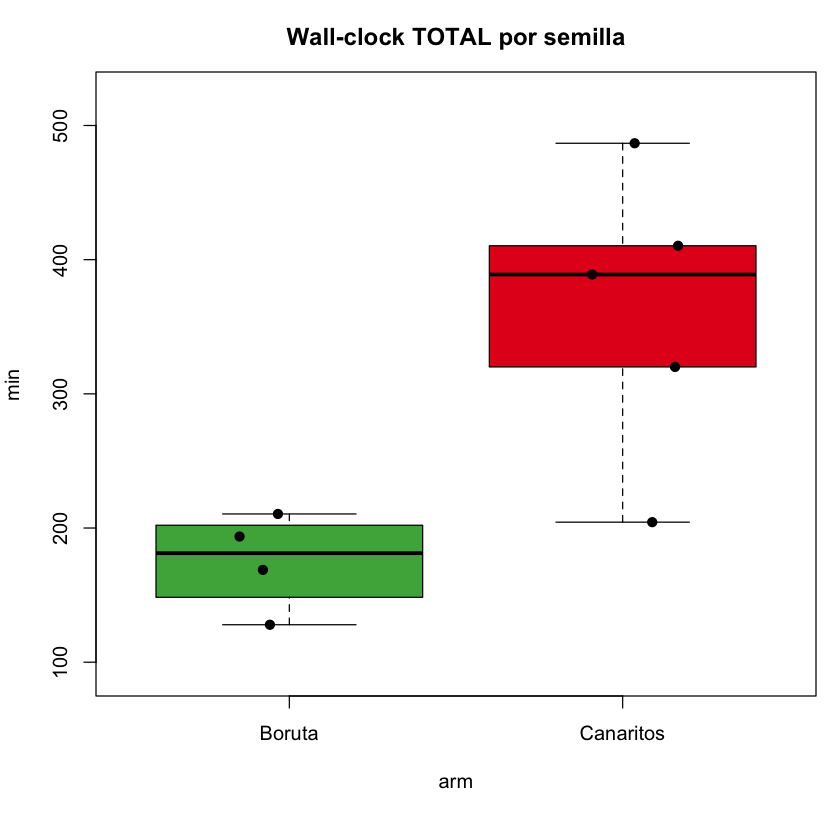

In [9]:
# solo corridas completas (excluye Boruta s493747 truncada)
sw <- stages_wide[completo == TRUE]

# --- plot 1: wall-clock total
op <- par(mar = c(6, 4, 3, 1))
boxplot(total ~ arm, data = sw, col = c("#4DAF4A", "#E41A1C"),
        ylab = "min", main = "Wall-clock TOTAL por semilla",
        ylim = extendrange(sw$total, f = 0.1))
points(jitter(as.integer(factor(sw$arm))), sw$total, pch = 19)
par(op)

tw <- dcast(sw, seed ~ arm, value.var = "total")
setnames(tw, c(ARM_A, ARM_B), c("total_A", "total_B"))
tw[, delta_B_minus_A := round(total_B - total_A, 1)]
tw[, ratio_B_A := round(total_B / total_A, 2)]
print(tw)

okt <- complete.cases(tw[, .(total_A, total_B)])
if (sum(okt) >= 3) print(wilcox.test(tw$total_B[okt], tw$total_A[okt], paired = TRUE))
cat(sprintf("\nTotal medio — %s: %.0f min | %s: %.0f min\n",
            ARM_A, mean(tw$total_A, na.rm = TRUE),
            ARM_B, mean(tw$total_B, na.rm = TRUE)))

Key: <seed>
     seed      fs_B     fs_A delta_B_minus_A
    <int>     <num>    <num>           <num>
1: 169327  86.37855 2.142694            84.2
2: 218249 114.60879 2.112772           112.5
3: 493747        NA 1.982604              NA
4: 644857 115.28590 2.033279           113.3
5: 655103  86.82063 1.937931            84.9

	Wilcoxon signed rank exact test

data:  tw_fs$fs_B[okf] and tw_fs$fs_A[okf]
V = 10, p-value = 0.125
alternative hypothesis: true location shift is not equal to 0


FS medio — Canaritos: 2.0 min | Boruta: 100.8 min


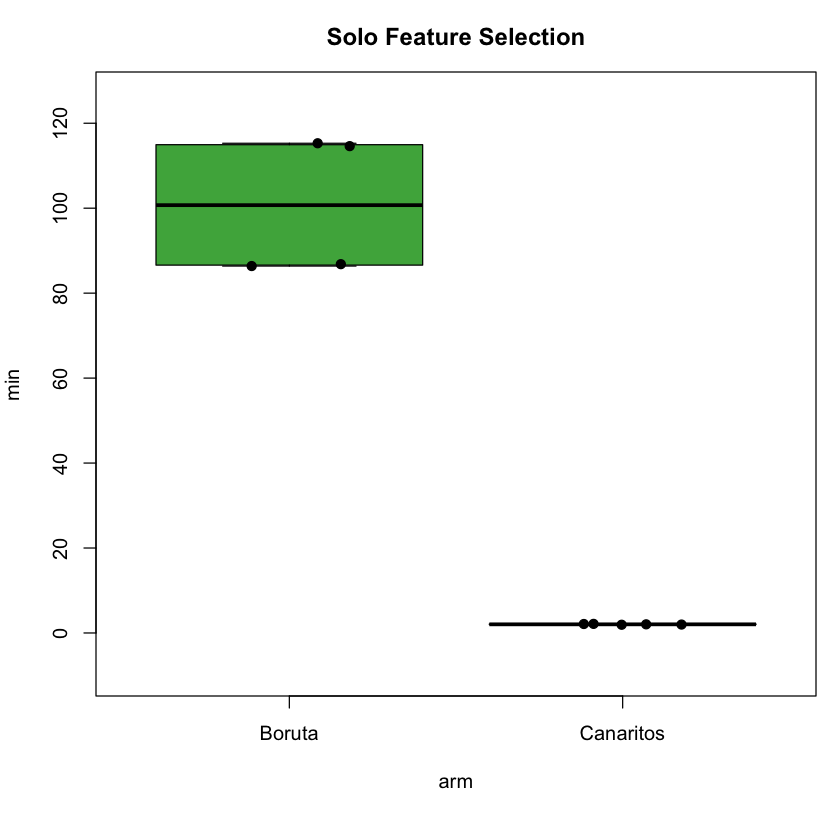

In [10]:
# --- plot 2: solo feature selection (solo corridas completas)
sw <- stages_wide[completo == TRUE]
op <- par(mar = c(6, 4, 3, 1))
boxplot(FS ~ arm, data = sw, col = c("#4DAF4A", "#E41A1C"),
        ylab = "min", main = "Solo Feature Selection",
        ylim = extendrange(sw$FS, f = 0.1))
points(jitter(as.integer(factor(sw$arm))), sw$FS, pch = 19)
par(op)

tw_fs <- dcast(sw, seed ~ arm, value.var = "FS")
setnames(tw_fs, c(ARM_A, ARM_B), c("fs_A", "fs_B"))
tw_fs[, delta_B_minus_A := round(fs_B - fs_A, 1)]
print(tw_fs)

okf <- complete.cases(tw_fs[, .(fs_A, fs_B)])
if (sum(okf) >= 3) print(wilcox.test(tw_fs$fs_B[okf], tw_fs$fs_A[okf], paired = TRUE))
cat(sprintf("\nFS medio — %s: %.1f min | %s: %.1f min\n",
            ARM_A, mean(tw_fs$fs_A, na.rm = TRUE),
            ARM_B, mean(tw_fs$fs_B, na.rm = TRUE)))

        stage    Boruta  Canaritos
       <char>     <num>      <num>
1: Semillerio 32.522136 226.369331
2:         BO 27.109909 118.484731
3:       otro  9.930690  10.369994
4:     Kaggle  3.894256   4.834639
5:         FS 80.621955   2.041856

OJO: el trade-off esperado es FS(Canaritos) rapido pero downstream pesado (muchas vars)
vs FS(Boruta) lento pero downstream liviano (pocas vars). Mirar 'total', no solo FS.


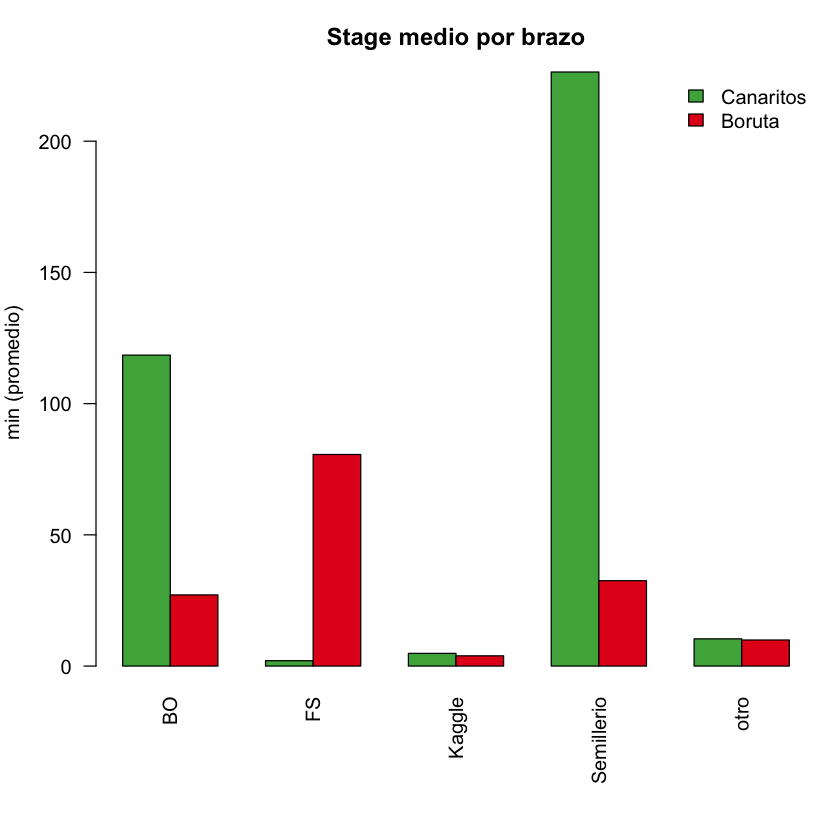

In [11]:
# promedio de cada stage por brazo
stage_mean <- stages_all[, .(min_medio = mean(min)), by = .(arm, stage)]
out_m <- dcast(stage_mean, stage ~ arm, value.var = "min_medio")
print(out_m[order(-get(ARM_A))])

op <- par(mar = c(7, 4, 3, 1))
sm <- t(as.matrix(out_m[, .(get(ARM_A), get(ARM_B))]))
rownames(sm) <- c(ARM_A, ARM_B)
colnames(sm) <- out_m$stage
barplot(sm, beside = TRUE,
        col = c("#4DAF4A", "#E41A1C"), ylab = "min (promedio)",
        main = "Stage medio por brazo", las = 2)
legend("topright", c(ARM_A, ARM_B), fill = c("#4DAF4A", "#E41A1C"), bty = "n")
par(op)
cat("
OJO: el trade-off esperado es FS(Canaritos) rapido pero downstream pesado (muchas vars)
vs FS(Boruta) lento pero downstream liviano (pocas vars). Mirar 'total', no solo FS.\n")

## 2. Cross-check con logs de corrida

Estados `FIN OK/ERROR` desde `corrida_exp{EXP}.log` (si existen). Solo valida completitud; los timings finos vienen de papermill.

In [12]:
parse_status <- function(path) {
  pat <- "===\\s*(FIN(?: OK| ERROR)?)\\s+SEMILLA=(\\d+)\\s+(.*?)\\s*((?:Mon|Tue|Wed|Thu|Fri|Sat|Sun)\\s+\\w{3}\\s+.*)\\s*==="
  lines <- readLines(path, warn = FALSE)
  m <- regmatches(lines, regexec(pat, lines))
  rbindlist(lapply(Filter(function(x) length(x) == 5, m), function(mi)
    data.table(seed = as.integer(mi[3]), status = trimws(sub("^FIN\\s*", "", mi[2])))))
}

for (e in c(EXP_A, EXP_B)) {
  lf <- sprintf("corrida_exp%d.log", e)
  if (file.exists(lf)) {
    cat(sprintf("--- exp%d (%s)\n", e,
                if (e == EXP_A) ARM_A else ARM_B))
    st <- parse_status(lf)[, .SD[1], by = seed][order(seed)]
    print(st)
    miss <- setdiff(SEEDS, st[status == "OK"]$seed)
    if (length(miss)) cat("Sin FIN OK:", paste(miss, collapse = ", "), "\n")
  } else cat(sprintf("corrida_exp%d.log no existe (ok, timings via papermill)\n", e))
}

--- exp9500 (Canaritos)
     seed status
    <int> <char>
1: 218249     OK
2: 644857     OK
Sin FIN OK: 493747, 655103, 169327 
--- exp9503 (Boruta)
     seed status
    <int> <char>
1: 169327     OK
2: 655103     OK
Sin FIN OK: 644857, 218249, 493747 


## 3. R1 Compresión — `k` variables seleccionadas y solapamiento

`k` real post-selección: columnas del dataset tras el paso FS (desde la salida `ncol(dataset)` + `colnames(dataset)` del notebook) que pertenecen al ranking (`canaritos.txt` / `boruta.txt`).

In [13]:
# ---------- Funnel completo de reducción (para slides) ----------
# cols post-FE = 1518 en todas las semillas (celda ncol(dataset) previa a la
# seleccion, verificada en salida_corrida*.ipynb: 202 -> 1197 -> 1518)
COLS_POST_FE <- 1518L

kept_from_nb <- function(nbfile, rk_names, selpat) {
  nb <- jsonlite::fromJSON(nbfile, simplifyVector = FALSE)
  hit <- FALSE
  for (cc in nb$cells) {
    src <- paste(unlist(cc$source), collapse = "")
    if (grepl(selpat, src) && !grepl("<- function", src)) hit <- TRUE
    if (!hit || cc$cell_type != "code") next
    txt <- ""
    for (o in cc$outputs) {
      t <- o$text
      d2 <- if (is.null(o$data)) NULL else o$data[["text/plain"]]
      txt <- paste(txt, paste(unlist(t), collapse = ""), paste(unlist(d2), collapse = ""))
    }
    if (length(gregexpr('"', txt)[[1]]) > 10) {
      cols <- gsub('"', "", regmatches(txt, gregexpr('"[^"]+"', txt))[[1]])
      return(intersect(cols, rk_names))
    }
  }
  character(0)
}

funnel <- rbindlist(lapply(SEEDS, function(s) {
  rkA <- fread(sprintf("exp/WF9500_s%d/canaritos.txt", s))
  ncan <- sum(grepl("canarito", rkA$Feature, ignore.case = TRUE))
  kA <- length(kept_from_nb(sprintf("exp/WF9500_s%d/salida_corrida.ipynb", s),
                            rkA$Feature, "tb_importancia <- CanaritosAsesinos\\("))
  bf <- sprintf("exp/WF9503_s%d/boruta.txt", s)
  kB <- if (file.exists(bf)) length(readLines(bf)) - 1L else NA_integer_
  data.table(
    seed = s,
    p_in = COLS_POST_FE,
    k_canaritos = kA,
    k_boruta = kB,
    delta_k = kB - kA,
    jaccard = if (!is.na(kB)) {
      vb <- trimws(readLines(bf)[-1])
      va <- kept_from_nb(sprintf("exp/WF9500_s%d/salida_corrida.ipynb", s),
                         rkA$Feature, "tb_importancia <- CanaritosAsesinos\\(")
      round(length(intersect(va, vb)) / length(union(va, vb)), 3)
    } else NA_real_,
    # detalle del funnel Canaritos
    canaritos_inyectados = ncan,
    evaluadas_lgbm = COLS_POST_FE + ncan,
    filas_ranking = nrow(rkA),
    reales_con_gain = nrow(rkA) - ncan,
    muertas_sin_split = COLS_POST_FE - (nrow(rkA) - ncan)
  )
}))
funnel[]

cat(sprintf("\npromedios: k_canaritos=%.0f | k_boruta=%.1f | jaccard=%.3f | muertas_sin_split=%.0f (%.0f%%)\n",
            mean(funnel$k_canaritos), mean(funnel$k_boruta, na.rm = TRUE),
            mean(funnel$jaccard, na.rm = TRUE),
            mean(funnel$muertas_sin_split),
            100 * mean(funnel$muertas_sin_split) / COLS_POST_FE))

seed,p_in,k_canaritos,k_boruta,delta_k,jaccard,canaritos_inyectados,evaluadas_lgbm,filas_ranking,reales_con_gain,muertas_sin_split
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>
644857,1518,428,112,-316,0.219,303,1821,956,653,865
218249,1518,467,125,-342,0.238,303,1821,930,627,891
493747,1518,501,NA,NA,NA,301,1819,893,592,926
655103,1518,493,89,-404,0.171,301,1819,893,592,926
169327,1518,491,96,-395,0.181,301,1819,904,603,915



promedios: k_canaritos=476 | k_boruta=105.5 | jaccard=0.202 | muertas_sin_split=905 (60%)


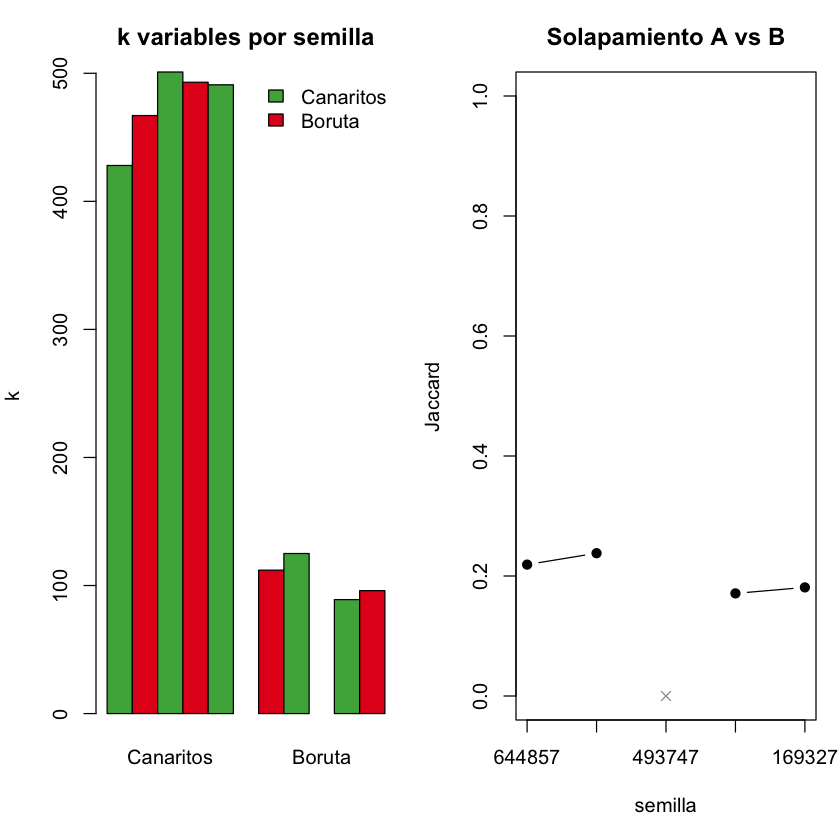

In [14]:
# ---------- plots de compresion (desde funnel) ----------
op <- par(mfrow = c(1, 2), mar = c(5, 4, 3, 1))
km <- as.matrix(funnel[, .(k_canaritos, k_boruta)])
rownames(km) <- funnel$seed
colnames(km) <- c(ARM_A, ARM_B)
barplot(km, beside = TRUE, col = c("#4DAF4A", "#E41A1C"),
        main = "k variables por semilla", ylab = "k")
legend("topright", c(ARM_A, ARM_B), fill = c("#4DAF4A", "#E41A1C"), bty = "n")
if (any(!is.na(funnel$jaccard))) {
  okj <- !is.na(funnel$jaccard)
  plot(funnel$jaccard, type = "b", pch = 19, xaxt = "n", ylim = c(0, 1),
       xlab = "semilla", ylab = "Jaccard", main = "Solapamiento A vs B")
  axis(1, at = seq_len(nrow(funnel)), labels = funnel$seed)
  points(seq_len(nrow(funnel))[!okj], rep(0, sum(!okj)), pch = 4, col = "grey60")
}
par(op)

## 3.bis R2 Internals — rank plot Canaritos y boxplots Boruta

Misma semilla en ambos brazos. Izquierda: dónde corta la banda de canaritos (sobre **posición** en `lgb.importance`, que es como corta el código: `mediana(pos) + 2·sd(pos)`). Derecha: `meanImp` de Boruta por decisión y tasa de supervivencia por familia de variables.

umbral=783.2 | vivas=491 | asesinadas(rankeadas)=112 | sin split=915


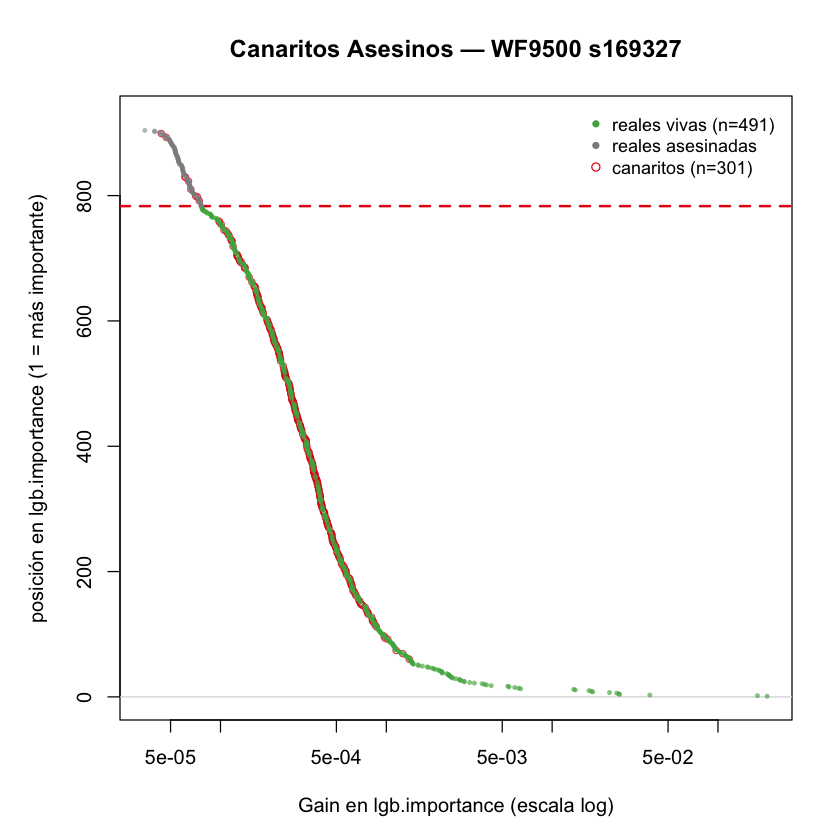

In [15]:
SEED_PLOT <- 169327   # semilla representativa (k=491, media ~476)

# ---------- Canaritos: rank plot con la regla real ----------
d <- fread(sprintf("exp/WF9500_s%d/canaritos.txt", SEED_PLOT))
setorder(d, -Gain)
d[, rank := seq_len(.N)]
d[, es_canarito := grepl("canarito", Feature, ignore.case = TRUE)]
gve_pos <- d[es_canarito == TRUE]$rank
umbral <- median(gve_pos) + 2 * sd(gve_pos)   # regla REAL: corte por posicion
d[, sobrevive := rank < umbral]
n_vivas <- d[es_canarito == FALSE & sobrevive == TRUE, .N]
n_muertas_rank <- d[es_canarito == FALSE & sobrevive == FALSE, .N]
n_sin_split <- 1518 - (nrow(d) - sum(d$es_canarito))

op <- par(mar = c(5, 5, 4, 2))
plot(rank ~ Gain, data = d, log = "x", type = "n",
     ylim = c(0, max(d$rank) * 1.02),
     xlab = "Gain en lgb.importance (escala log)",
     ylab = "posición en lgb.importance (1 = más importante)",
     main = sprintf("Canaritos Asesinos — WF9500 s%d", SEED_PLOT))
abline(h = 0, col = "grey85")
xr <- par("usr")
rect(xr[1], umbral, xr[2], max(d$rank) * 1.02,
     col = adjustcolor("#E41A1C", 0.07), border = NA)
abline(h = umbral, col = "#E41A1C", lwd = 2, lty = 2)
points(rank ~ Gain, data = d[es_canarito == TRUE], pch = 1, cex = 0.7,
       col = adjustcolor("#E41A1C", 0.75))
points(rank ~ Gain, data = d[es_canarito == FALSE & sobrevive == TRUE],
       pch = 16, cex = 0.55, col = adjustcolor("#4DAF4A", 0.65))
points(rank ~ Gain, data = d[es_canarito == FALSE & sobrevive == FALSE],
       pch = 16, cex = 0.55, col = adjustcolor("grey55", 0.55))
text(x = xr[2] * 0.5, y = umbral, pos = 1, col = "#E41A1C", cex = 0.95,
     label = sprintf("umbral = mediana(pos canaritos) + 2·sd(pos) = %.0f", umbral))
text(x = xr[2] * 0.5, y = max(d$rank) * 0.98, pos = 1, col = "#E41A1C", cex = 0.9,
     label = sprintf("zona de asesinato: %d reales + %d sin ningún split",
                     n_muertas_rank, n_sin_split))
legend("topright", inset = 0.01,
       legend = c(sprintf("reales vivas (n=%d)", n_vivas),
                  "reales asesinadas",
                  sprintf("canaritos (n=%d)", sum(d$es_canarito))),
       pch = c(16, 16, 1), col = c("#4DAF4A", "grey55", "#E41A1C"),
       pt.cex = c(0.8, 0.8, 0.9), bty = "n", cex = 0.9)
par(op)
cat(sprintf("umbral=%.1f | vivas=%d | asesinadas(rankeadas)=%d | sin split=%d\n",
            umbral, n_vivas, n_muertas_rank, n_sin_split))

fam,n,vivas,tasa
<chr>,<int>,<int>,<dbl>
lag1/lag2,392,31,0.07908163
delta1/delta2,390,20,0.05128205
RF-leaf (arbolitos),320,6,0.01875000
base,196,25,0.12755102
tend6,196,14,0.07142857


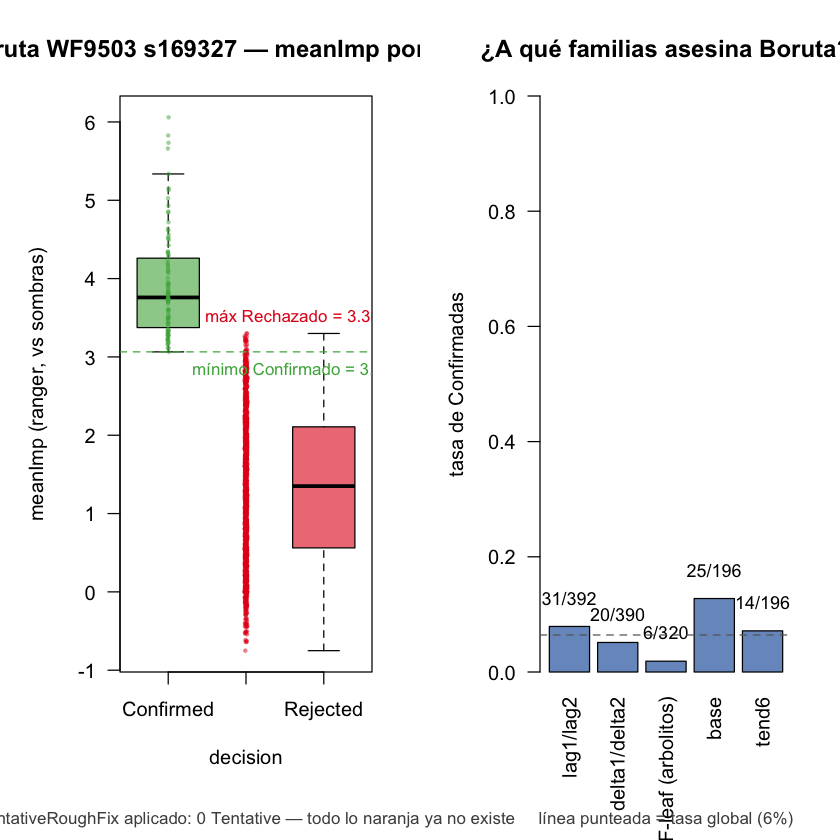

In [16]:
# ---------- Boruta: meanImp por decision + familias ----------
st <- fread(sprintf("exp/WF9503_s%d/boruta_stats.txt", SEED_PLOT))
bt <- fread(sprintf("exp/WF9503_s%d/boruta.txt", SEED_PLOT))
st[, decision := fifelse(variable %in% bt$variable, "Confirmed", decision)]
st[, decision := factor(decision, levels = c("Confirmed", "Tentative", "Rejected"))]

familia <- function(v) {
  ifelse(grepl("^rf_", v), "RF-leaf (arbolitos)",
  ifelse(grepl("_lag[12]$", v), "lag1/lag2",
  ifelse(grepl("_delta[12]$", v), "delta1/delta2",
  ifelse(grepl("_tend6$", v), "tend6",
  ifelse(grepl("_(min|max|avg|ratioavg|ratiomax)$", v), "FE hist otros",
         "base")))))
}
st[, fam := familia(variable)]

cols <- c(Confirmed = "#4DAF4A", Tentative = "#FF7F00", Rejected = "#E41A1C")
op <- par(mfrow = c(1, 2), mar = c(7, 5, 4, 2))
lv <- droplevels(st$decision)
boxplot(meanImp ~ decision, data = st, col = adjustcolor(cols, 0.6),
        ylab = "meanImp (ranger, vs sombras)",
        main = sprintf("Boruta WF9503 s%d — meanImp por decisión", SEED_PLOT),
        outline = FALSE, las = 1, ylim = range(st$meanImp))
for (l in levels(lv)) {
  dd <- st[decision == l]$meanImp
  points(jitter(rep(which(levels(lv) == l), length(dd)), 0.4), dd,
         pch = 16, cex = 0.5, col = adjustcolor(cols[[l]], 0.5))
}
conf_min <- min(st[decision == "Confirmed"]$meanImp)
rej_max  <- max(st[decision == "Rejected"]$meanImp)
abline(h = conf_min, lty = 2, col = "#4DAF4A")
text(2.6, conf_min, pos = 1, cex = 0.85, col = "#4DAF4A",
     label = sprintf("mínimo Confirmado = %.2f", conf_min))
text(2.6, rej_max, pos = 3, cex = 0.85, col = "#E41A1C",
     label = sprintf("máx Rechazado = %.2f", rej_max))
mtext(sprintf("TentativeRoughFix aplicado: %d Tentative — todo lo naranja ya no existe",
              sum(st$decision == "Tentative")),
      side = 1, line = 5.5, cex = 0.85, col = "grey30")

fam_tab <- st[, .(n = .N, vivas = sum(decision == "Confirmed")), by = fam][order(-n)]
fam_tab[, tasa := vivas / n]
barplot(fam_tab$tasa, names.arg = fam_tab$fam, las = 2, ylim = c(0, 1),
        col = adjustcolor("#4173b3", 0.75), ylab = "tasa de Confirmadas",
        main = "¿A qué familias asesina Boruta?")
text(barplot(fam_tab$tasa, plot = FALSE), y = fam_tab$tasa + 0.05,
     labels = sprintf("%d/%d", fam_tab$vivas, fam_tab$n), cex = 0.9)
abline(h = sum(fam_tab$vivas) / sum(fam_tab$n), lty = 2, col = "grey40")
mtext(sprintf("línea punteada = tasa global (%.0f%%)",
              100 * sum(fam_tab$vivas) / sum(fam_tab$n)),
      side = 1, line = 5.5, cex = 0.85, col = "grey30")
par(op)

fam_tab[]

## 4. R3 Surrogate — mejor AUC del BO (pareado)

Desde `BO_log.txt` (TSV del opt path de mlrMBO): `y` = AUC en validate 202107, `exec.time` en segundos.

seed,bo_min_A,auc_A,bo_min_B,auc_B
<int>,<dbl>,<dbl>,<dbl>,<dbl>
644857,79.4,0.938684,29.3,0.935205
218249,92.3,0.939281,31.2,0.934986
493747,198.9,0.940455,NA,NA
655103,104.2,0.939694,19.6,0.932796
169327,116.2,0.939657,27.3,0.933638



Delta medio AUC (B - A): -0.00517 | gana B en 0/4 seeds

	Paired t-test

data:  bo_auc$auc_B[okb] and bo_auc$auc_A[okb]
t = -6.6177, df = 3, p-value = 0.007027
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.007660333 -0.002685167
sample estimates:
mean difference 
    -0.00517275 



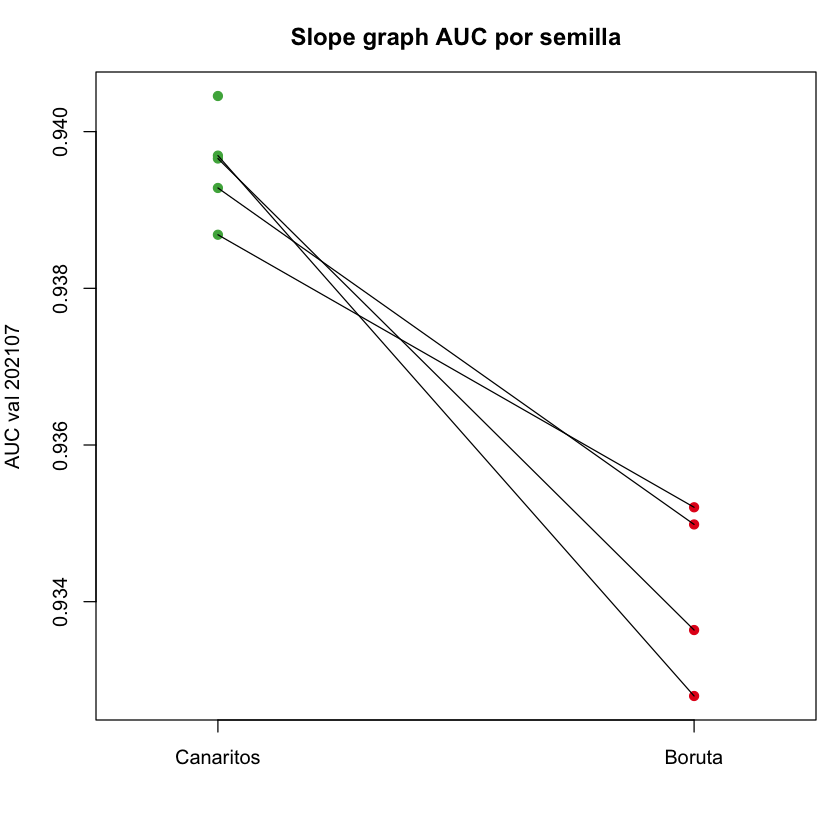

In [17]:
bo_stats <- function(exp, seed) {
  f <- file.path(exp_dir(exp, seed), "BO_log.txt")
  out <- data.table(bo_min = NA_real_, auc_max = NA_real_, n_iter = NA_integer_)
  if (!file.exists(f)) return(out)
  bo <- fread(f)
  if (!is.null(bo$y)) out$auc_max <- round(max(bo$y, na.rm = TRUE), 6)
  if (!is.null(bo$exec.time)) out$bo_min <- round(sum(bo$exec.time, na.rm = TRUE) / 60, 1)
  out$n_iter <- nrow(bo)
  out
}

bo_auc <- rbindlist(lapply(SEEDS, function(s) {
  a <- bo_stats(EXP_A, s); b <- bo_stats(EXP_B, s)
  data.table(seed = s, bo_min_A = a$bo_min, auc_A = a$auc_max,
             bo_min_B = b$bo_min, auc_B = b$auc_max)
}))
bo_auc[]

okb <- complete.cases(bo_auc[, .(auc_A, auc_B)])
if (sum(okb) >= 2) {
  rng <- range(c(bo_auc$auc_A, bo_auc$auc_B), na.rm = TRUE)
  op <- par(mar = c(5, 4, 3, 1))
  plot(rep(1, nrow(bo_auc)), bo_auc$auc_A, xlim = c(0.8, 2.2), ylim = rng,
       axes = FALSE, xlab = "", ylab = "AUC val 202107", pch = 19, col = "#4DAF4A",
       main = "Slope graph AUC por semilla")
  points(rep(2, nrow(bo_auc)), bo_auc$auc_B, pch = 19, col = "#E41A1C")
  segments(rep(1, nrow(bo_auc))[okb], bo_auc$auc_A[okb],
           rep(2, nrow(bo_auc))[okb], bo_auc$auc_B[okb])
  axis(1, at = 1:2, labels = c(ARM_A, ARM_B)); axis(2); box()
  par(op)
  cat(sprintf("\nDelta medio AUC (B - A): %.5f | gana B en %d/%d seeds\n",
              mean(bo_auc$auc_B[okb] - bo_auc$auc_A[okb]),
              sum(bo_auc$auc_B[okb] > bo_auc$auc_A[okb]), sum(okb)))
  if (sum(okb) >= 3) print(t.test(bo_auc$auc_B[okb], bo_auc$auc_A[okb], paired = TRUE))
}

## 5. R4 Money — ganancia vs envios (Kaggle public LB)

El truth local de 202109 viene sin etiquetar, así que las curvas de ganancia salen del **export de Kaggle**. Cuando lo tengas, guardar un CSV en `datasets/kaggle_scores_9500_9503_9504.csv` (o `datasets/kaggle_scores.csv` genérico) con columnas:

```
exp,seed,envios,public
9500,644857,8000,123.45
...
```

(`exp` = 9500 | 9503 | 9504, `envios` = corte 8000–12000, `public` = score LB de esa submission.) La celda de abajo arma todo automáticamente cuando exista el archivo.

Key: <seed>
     seed  Boruta Canaritos
    <int>   <num>     <num>
1: 169327 426.248   459.498
2: 218249 438.164   444.498
3: 493747      NA   447.164
4: 644857 425.081   457.414
5: 655103 424.748   449.248

Delta best-ganancia media (B - A): -24.1 | gana B en 0/4

	Paired t-test

data:  gb[okg] and ga[okg]
t = -3.8627, df = 3, p-value = 0.03068
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -43.963656  -4.244844
sample estimates:
mean difference 
      -24.10425 


	Wilcoxon signed rank exact test

data:  gb[okg] and ga[okg]
V = 0, p-value = 0.125
alternative hypothesis: true location shift is not equal to 0



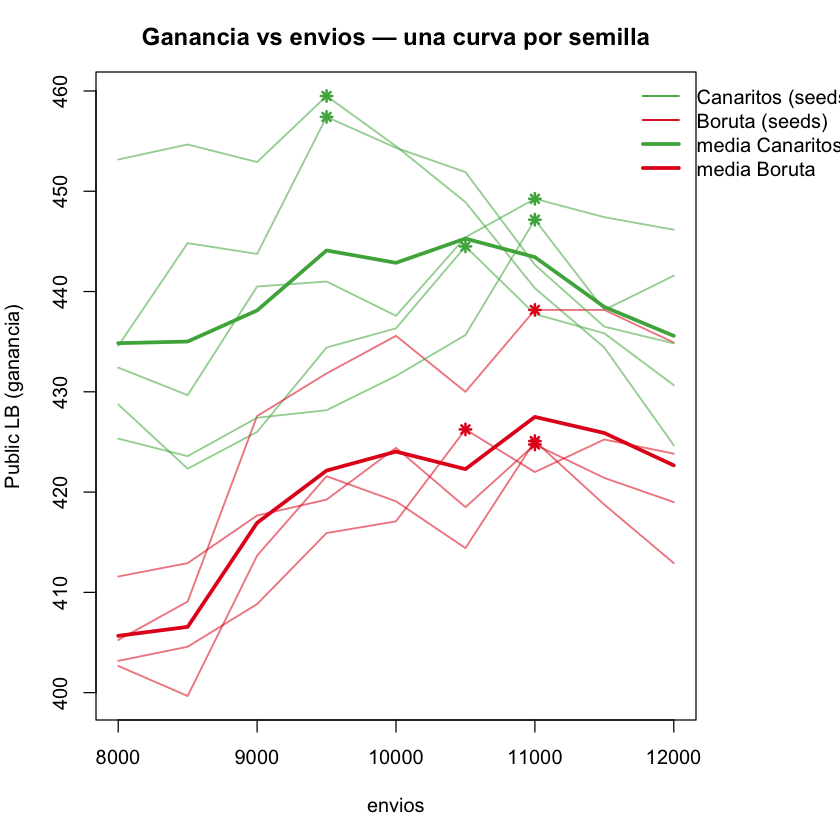

In [18]:
scores_f3 <- "datasets/kaggle_scores_9500_9503_9504.csv"
scores_f2 <- "datasets/kaggle_scores_9500_9503.csv"
scores_fg <- "datasets/kaggle_scores.csv"
# priorizar el archivo con 9504, fallback a legacy
scores_f <- if (file.exists(scores_f3)) scores_f3 else if (file.exists(scores_fg)) scores_fg else scores_f2
lb_curves <- NULL
best_lb <- NULL
if (file.exists(scores_f)) {
  sc <- fread(scores_f)
  # mapeo exp -> arm (soporta 2 o 3 brazos)
  exp_to_arm <- c("9500"=ARM_A, "9503"=ARM_B, "9504"=ARM_C)
  # si no existe EXP_C/ARM_C (notebook viejo), definir fallback
  if (!exists("EXP_C")) { EXP_C <- 9504L; ARM_C <- "Warmstart9504" }
  sc[, arm := exp_to_arm[as.character(exp)]]
  sc <- sc[!is.na(arm)]
  lb_curves <- sc[, .(gan_mean = mean(public), gan_sd = sd(public)), by = .(arm, envios)]
  best_lb <- sc[order(-public), .SD[1], by = .(arm, seed)]

  # paleta para 3 brazos
  cols <- setNames(c("#4DAF4A", "#E41A1C", "#377EB8"), c(ARM_A, ARM_B, ARM_C))
  # asegurar que ARM_C tenga color incluso si no hay datos
  ltys <- setNames(c(1,1,2), c(ARM_A, ARM_B, ARM_C))
  op <- par(mar = c(5, 4, 3, 6))
  plot(range(sc$envios), range(sc$public), type = "n",
       xlab = "envios", ylab = "Public LB (ganancia)",
       main = "Ganancia vs envios — una curva por semilla (9500/9503/9504)")
  # todas las curvas individuales, una linea por seed
  for (s in unique(sc$seed)) {
    for (a in unique(sc$arm)) {
      d <- sc[seed == s & arm == a][order(envios)]
      if (!nrow(d)) next
      lines(d$envios, d$public, col = adjustcolor(cols[[a]], 0.55), lwd = 1.5, lty = ltys[[a]])
      points(d$envios[which.max(d$public)], max(d$public),
             pch = 8, cex = 0.9, col = cols[[a]], lwd = 2)
    }
  }
  # media de cada brazo en grueso
  for (a in unique(lb_curves$arm)) {
    d <- lb_curves[arm == a][order(envios)]
    lines(d$envios, d$gan_mean, col = cols[[a]], lwd = 3, lty = ltys[[a]])
  }
  legend("topright", inset = c(-0.30, 0),
         legend = sprintf("%s (seeds=%d)", names(cols)[names(cols) %in% lb_curves$arm],
                          sapply(names(cols)[names(cols) %in% lb_curves$arm], function(a) uniqueN(sc[arm==a]$seed))),
         col = cols[names(cols) %in% lb_curves$arm],
         lwd = 3, lty = ltys[names(cols) %in% lb_curves$arm], bty = "n", xpd = TRUE)
  # segunda leyenda para medias vs individuales
  legend("bottomright", inset = c(-0.30, 0),
         legend = c("curva por semilla (fina)", "media brazo (gruesa)", "★ best por semilla"),
         lty = c(1,1,NA), pch = c(NA,NA,8), col = c("grey40","black","black"), bty = "n", xpd = TRUE)
  par(op)

  # tabla best por seed y brazo
  tiles <- dcast(best_lb, seed ~ arm, value.var = "public")
  print(tiles)
  # comparaciones pareadas: A vs B, A vs C, B vs C donde haya pares completos
  for (pair in list(c(ARM_A, ARM_B), c(ARM_A, ARM_C), c(ARM_B, ARM_C))) {
    if (all(pair %in% names(tiles))) {
      ga <- tiles[[pair[1]]]; gb <- tiles[[pair[2]]]
      okg <- complete.cases(ga, gb)
      if (sum(okg) >= 2) {
        cat(sprintf("\nDelta best-ganancia media (%s - %s): %.1f | gana %s en %d/%d\n",
                    pair[2], pair[1], mean(gb[okg] - ga[okg], na.rm=TRUE), pair[2], sum(gb[okg] > ga[okg]), sum(okg)))
        if (sum(okg) >= 3) {
          print(t.test(gb[okg], ga[okg], paired = TRUE))
          print(wilcox.test(gb[okg], ga[okg], paired = TRUE))
        }
      }
    }
  }
} else {
  cat("Todavia no hay", scores_f, "\n")
  print(data.table(seed = SEEDS, best_envios_A = NA_real_, best_public_A = NA_real_,
                   best_envios_B = NA_real_, best_public_B = NA_real_)[, -(1), drop = FALSE][])
  cat("\n-> Exportar scores de Kaggle y rellenar el CSV para activar esta seccion.\n")
  cat("Sugerencia: KAGGLE_CONFIG_DIR=. kaggle competitions submissions -c data-mining-senior-2026-b --csv --page-size 200 > datasets/kaggle/submissions_api_full.csv\n")
}


## 6. Decisión

In [19]:
summary_row <- function(label, a, b, lower_is_better = FALSE) {
  ok <- complete.cases(a, b); n <- sum(ok)
  if (n < 2) return(data.table(metric = label, media_A = mean(a, na.rm = TRUE),
                               media_B = mean(b, na.rm = TRUE), delta_BmA = NA_real_,
                               p_pareada = NA_real_, n = n, verdict = "insuficiente"))
  d <- b[ok] - a[ok]
  pv <- tryCatch(t.test(b[ok], a[ok], paired = TRUE)$p.value, error = function(e) NA_real_)
  win <- if (lower_is_better) sum(d < 0) else sum(d > 0)
  data.table(metric = label, media_A = round(mean(a[ok]), 2),
             media_B = round(mean(b[ok]), 2), delta_BmA = round(mean(d), 2),
             p_pareada = if (!is.na(pv)) signif(pv, 3) else NA_real_, n = n,
             verdict = sprintf("%s en %d/%d",
                               if (lower_is_better) "B mas rapido" else "B mejor", win, n))
}

comp <- rbind(
  summary_row("total_min",   stages_wide[arm == ARM_A]$total, stages_wide[arm == ARM_B]$total, lower_is_better = TRUE),
  summary_row("FS_min",      stages_wide[arm == ARM_A]$FS,    stages_wide[arm == ARM_B]$FS,    lower_is_better = TRUE),
  summary_row("BO_min",      stages_wide[arm == ARM_A]$BO,    stages_wide[arm == ARM_B]$BO,    lower_is_better = TRUE),
  summary_row("semillerio_min", stages_wide[arm == ARM_A]$Semillerio, stages_wide[arm == ARM_B]$Semillerio, lower_is_better = TRUE),
  summary_row("k_vars",      funnel$k_canaritos,              funnel$k_boruta,                 lower_is_better = TRUE),
  summary_row("auc_max_BO",  bo_auc$auc_A,                    bo_auc$auc_B)
)
if (!is.null(tiles)) {   # tiles esta alineado por seed (NA donde falta el par)
  comp <- rbind(comp, summary_row("best_public", tiles[[ARM_A]], tiles[[ARM_B]]))
  # si existe 9504, agregar comparaciones extra
  if (ARM_C %in% names(tiles)) {
    comp <- rbind(comp, summary_row("best_public_CvsA", tiles[[ARM_A]], tiles[[ARM_C]]))
    comp <- rbind(comp, summary_row("best_public_CvsB", tiles[[ARM_B]], tiles[[ARM_C]]))
  }
}
# si hay datos de exp9504 en filesystem, agregar filas opcionales (no rompe si no)
if (exists("stages_wide") && ARM_C %in% stages_wide$arm) {
  comp <- rbind(comp,
    summary_row("total_min_CvsA", stages_wide[arm == ARM_A]$total, stages_wide[arm == ARM_C]$total, lower_is_better=TRUE),
    summary_row("total_min_CvsB", stages_wide[arm == ARM_B]$total, stages_wide[arm == ARM_C]$total, lower_is_better=TRUE)
  )
}
print(comp)

cat("\n",
"LECTURA (hipotesis original vs evidencia):\n",
"  - Si FS(Boruta) >> FS(Canaritos) PERO total(B) <= total(A):\n",
"    Boruta cuesta mas arriba pero ahorra mucho abajo (menos features ->\n",
"    BO y semillerio mas rapidos). El argumento 'Canaritos es mas barato'\n",
"    caeria a nivel pipeline completo.\n",
"  - Degradacion: mirar delta_BmA de auc_max_BO y best_public.\n",
"    Sin senal fuerte (p alto) de B < A -> no hay degradacion.\n",
"  - Warmstart 9504: compara C vs A/B en best_public_CvsA / CvsB.\n",
"    Si C mejora ganancia con similar costo, valida warmstart.\n",
"")


           metric media_A media_B delta_BmA p_pareada     n             verdict
           <char>   <num>   <num>     <num>     <num> <int>              <char>
1:      total_min  362.10  142.15   -219.95  0.045700     5 B mas rapido en 4/5
2:         FS_min    2.04   80.62     78.58  0.020400     5 B mas rapido en 1/5
3:         BO_min  118.48   21.69    -96.80  0.022000     5 B mas rapido en 5/5
4: semillerio_min  226.37   26.02   -200.35  0.006610     5 B mas rapido en 5/5
5:         k_vars  469.75  105.50   -364.25  0.000424     4 B mas rapido en 4/4
6:     auc_max_BO    0.94    0.93     -0.01  0.007030     4      B mejor en 0/4
7:    best_public  452.66  428.56    -24.10  0.030700     4      B mejor en 0/4

LECTURA (hipotesis original vs evidencia):
  - Si FS(Boruta) >> FS(Canaritos) PERO total(B) <= total(A):
    Boruta cuesta mas arriba pero ahorra mucho abajo (menos features ->
    BO y semillerio mas rapidos). El argumento 'Canaritos es mas barato'
    caeria a nivel pipeline c